# Human vs Machine Prediction Analysis

This notebook reproduces the evaluation and figures from the paper:

**"Predicting Juror Predisposition Using Machine Learning: A Comparative Study of Human and Algorithmic Jury Selection"**

## What this notebook does:
- Compares ML models (Random Forest, KNN) vs human experts
- Computes accuracy, precision, recall, F1
- Performs statistical testing (McNemar test, bootstrap CI)
- Analyzes error overlap between humans and models
- Generates publication-ready figures

## Requirements:
- Python 3.8+
- pandas, numpy, sklearn, seaborn, statsmodels

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics and statistical test
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from statsmodels.stats.contingency_tables import mcnemar

# Display settings for cleaner notebook tables
pd.options.display.float_format = "{:.3f}".format

# Plot styling for publication-friendly figures
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 300,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [2]:
def paired_bootstrap_accuracy_diff(
    y_true: pd.Series,
    y_pred_model: pd.Series,
    y_pred_human: pd.Series,
    n_bootstrap: int = 5000,
    seed: int = 42,
) -> dict:
    """
    Estimate the paired difference in accuracy between a model and the human baseline
    using bootstrap resampling.

    We resample rows with replacement, compute model accuracy and human accuracy on
    each resample, and then track the distribution of their differences.
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        acc_model = accuracy_score(y_true.iloc[idx], y_pred_model.iloc[idx])
        acc_human = accuracy_score(y_true.iloc[idx], y_pred_human.iloc[idx])

        diffs.append(acc_model - acc_human)

    diffs = np.asarray(diffs)

    return {
        "diffs": diffs,
        "diff_mean": diffs.mean(),
        "diff_low": np.percentile(diffs, 2.5),
        "diff_high": np.percentile(diffs, 97.5),
    }


def mcnemar_test(y_true: pd.Series, y_pred_model: pd.Series, y_pred_human: pd.Series) -> dict:
    """
    Run McNemar's test comparing two predictors on the same examples.

    b = model correct / human wrong
    c = model wrong / human correct

    Exact McNemar is used for small discordant counts; otherwise the continuity-corrected
    asymptotic version is used.
    """
    model_correct = y_pred_model == y_true
    human_correct = y_pred_human == y_true

    table = pd.crosstab(model_correct, human_correct).reindex(
        index=[False, True],
        columns=[False, True],
        fill_value=0,
    )

    b = table.loc[True, False]
    c = table.loc[False, True]

    if b + c < 25:
        result = mcnemar(table, exact=True)
    else:
        result = mcnemar(table, exact=False, correction=True)

    return {
        "b": b,
        "c": c,
        "p_value": result.pvalue,
    }


def compute_metrics(y_true: pd.Series, y_pred: pd.Series) -> dict:
    """
    Compute standard binary classification metrics.
    """
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def evaluate_model(
    name: str,
    y_true: pd.Series,
    y_pred_model: pd.Series,
    y_human: pd.Series,
    n_bootstrap: int = 5000,
) -> dict:
    """
    Build a single summary row for a machine learning model:
    - classification metrics
    - paired bootstrap difference vs human baseline
    - McNemar significance test vs human baseline
    """
    metrics = compute_metrics(y_true, y_pred_model)
    diff_boot = paired_bootstrap_accuracy_diff(
        y_true=y_true,
        y_pred_model=y_pred_model,
        y_pred_human=y_human,
        n_bootstrap=n_bootstrap,
    )
    mc = mcnemar_test(y_true, y_pred_model, y_human)

    return {
        "Model": name,
        **metrics,
        "Delta_Accuracy_vs_Human": diff_boot["diff_mean"],
        "Delta_CI_Low": diff_boot["diff_low"],
        "Delta_CI_High": diff_boot["diff_high"],
        "McNemar_b": mc["b"],
        "McNemar_c": mc["c"],
        "McNemar_p": mc["p_value"],
        "Significant_at_0_05": mc["p_value"] < 0.05,
    }


def evaluate_human(name: str, y_true: pd.Series, y_human: pd.Series) -> dict:
    """
    Build the summary row for the human baseline.
    Statistical comparison fields are left as NaN because the baseline is being
    compared against itself.
    """
    metrics = compute_metrics(y_true, y_human)

    return {
        "Model": name,
        **metrics,
        "Delta_Accuracy_vs_Human": np.nan,
        "Delta_CI_Low": np.nan,
        "Delta_CI_High": np.nan,
        "McNemar_b": np.nan,
        "McNemar_c": np.nan,
        "McNemar_p": np.nan,
        "Significant_at_0_05": np.nan,
    }

In [3]:
# Update this path if needed
DATA_PATH = "/content/human_model_values.csv"

# Read the evaluation file
df = pd.read_csv(DATA_PATH)

# Columns required for this notebook
required_cols = {
    "y_true",
    "y_pred_rf",
    "y_pred_knn",
    "human_expert",
    "human_expert_2",
    "human_expert_3",
}

missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Build a majority-vote human label from the three human consultants
human_cols = ["human_expert", "human_expert_2", "human_expert_3"]
df["majority_vote"] = (df[human_cols].sum(axis=1) >= 2).astype(int)

# Define the key series once so later cells stay clean
y_true = df["y_true"].astype(int)
y_rf = df["y_pred_rf"].astype(int)
y_knn = df["y_pred_knn"].astype(int)
y_human = df["majority_vote"].astype(int)

print(f"Loaded {len(df)} rows.")
df.head()

Loaded 137 rows.


,Unnamed: 0,y_true,y_pred_rf,y_pred_knn,human_expert,human_expert_2,human_expert_3,majority_vote
0,0,0,0,0,1,1,0,1
1,2,1,1,1,0,1,0,0
2,3,0,0,0,0,0,0,0
3,4,1,1,1,1,1,0,1
4,6,0,0,0,0,0,0,0


In [4]:
rows = [
    evaluate_human("Human (Majority Vote)", y_true, y_human),
    evaluate_model("Random Forest", y_true, y_rf, y_human),
    evaluate_model("KNN", y_true, y_knn, y_human),
]

results_df = pd.DataFrame(rows)

print("Evaluation summary:")
display(results_df)

Evaluation summary:


,Model,Accuracy,Precision,Recall,F1,Delta_Accuracy_vs_Human,Delta_CI_Low,Delta_CI_High,McNemar_b,McNemar_c,McNemar_p,Significant_at_0_05
0,Human (Majority Vote),0.693,0.720,0.756,0.738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,0.818,0.827,0.859,0.843,0.123,0.058,0.197,21.000,4.000,0.001,True
2,KNN,0.796,0.784,0.885,0.831,0.101,0.022,0.190,24.000,10.000,0.026,True


In [5]:
# Pull model rows for easier printing
rf_row = results_df.loc[results_df["Model"] == "Random Forest"].iloc[0]
knn_row = results_df.loc[results_df["Model"] == "KNN"].iloc[0]

print("=== Random Forest vs Human ===")
print(f"Mean accuracy difference: {rf_row['Delta_Accuracy_vs_Human']:.3f}")
print(f"95% CI: [{rf_row['Delta_CI_Low']:.3f}, {rf_row['Delta_CI_High']:.3f}]")
print(
    f"McNemar: b={int(rf_row['McNemar_b'])}, "
    f"c={int(rf_row['McNemar_c'])}, "
    f"p={rf_row['McNemar_p']:.4f}"
)

print("\n=== KNN vs Human ===")
print(f"Mean accuracy difference: {knn_row['Delta_Accuracy_vs_Human']:.3f}")
print(f"95% CI: [{knn_row['Delta_CI_Low']:.3f}, {knn_row['Delta_CI_High']:.3f}]")
print(
    f"McNemar: b={int(knn_row['McNemar_b'])}, "
    f"c={int(knn_row['McNemar_c'])}, "
    f"p={knn_row['McNemar_p']:.4f}"
)

=== Random Forest vs Human ===
Mean accuracy difference: 0.123
95% CI: [0.058, 0.197]
McNemar: b=21, c=4, p=0.0014

=== KNN vs Human ===
Mean accuracy difference: 0.101
95% CI: [0.022, 0.190]
McNemar: b=24, c=10, p=0.0258


In [6]:
# Create a compact dataframe showing predictions and correctness
error_df = pd.DataFrame({
    "y_true": y_true.reset_index(drop=True),
    "Human": y_human.reset_index(drop=True),
    "RF": y_rf.reset_index(drop=True),
    "KNN": y_knn.reset_index(drop=True),
})

# Mark whether each predictor was correct on each example
for col in ["Human", "RF", "KNN"]:
    error_df[f"{col}_correct"] = error_df[col] == error_df["y_true"]

# Encode error patterns as a three-bit string:
# 0 = correct, 1 = wrong
# Order is (Human, RF, KNN)
error_df["error_pattern"] = (
    (~error_df["Human_correct"]).astype(int).astype(str)
    + (~error_df["RF_correct"]).astype(int).astype(str)
    + (~error_df["KNN_correct"]).astype(int).astype(str)
)

# Count how often each error pattern occurs
pattern_counts = (
    error_df["error_pattern"]
    .value_counts()
    .sort_index()
    .rename_axis("error_pattern")
    .reset_index(name="count")
)

print("Error pattern counts:")
display(pattern_counts)

Error pattern counts:


,error_pattern,count
0,000,84
1,001,7
2,010,1
3,011,3
4,100,21
5,110,3
6,111,18


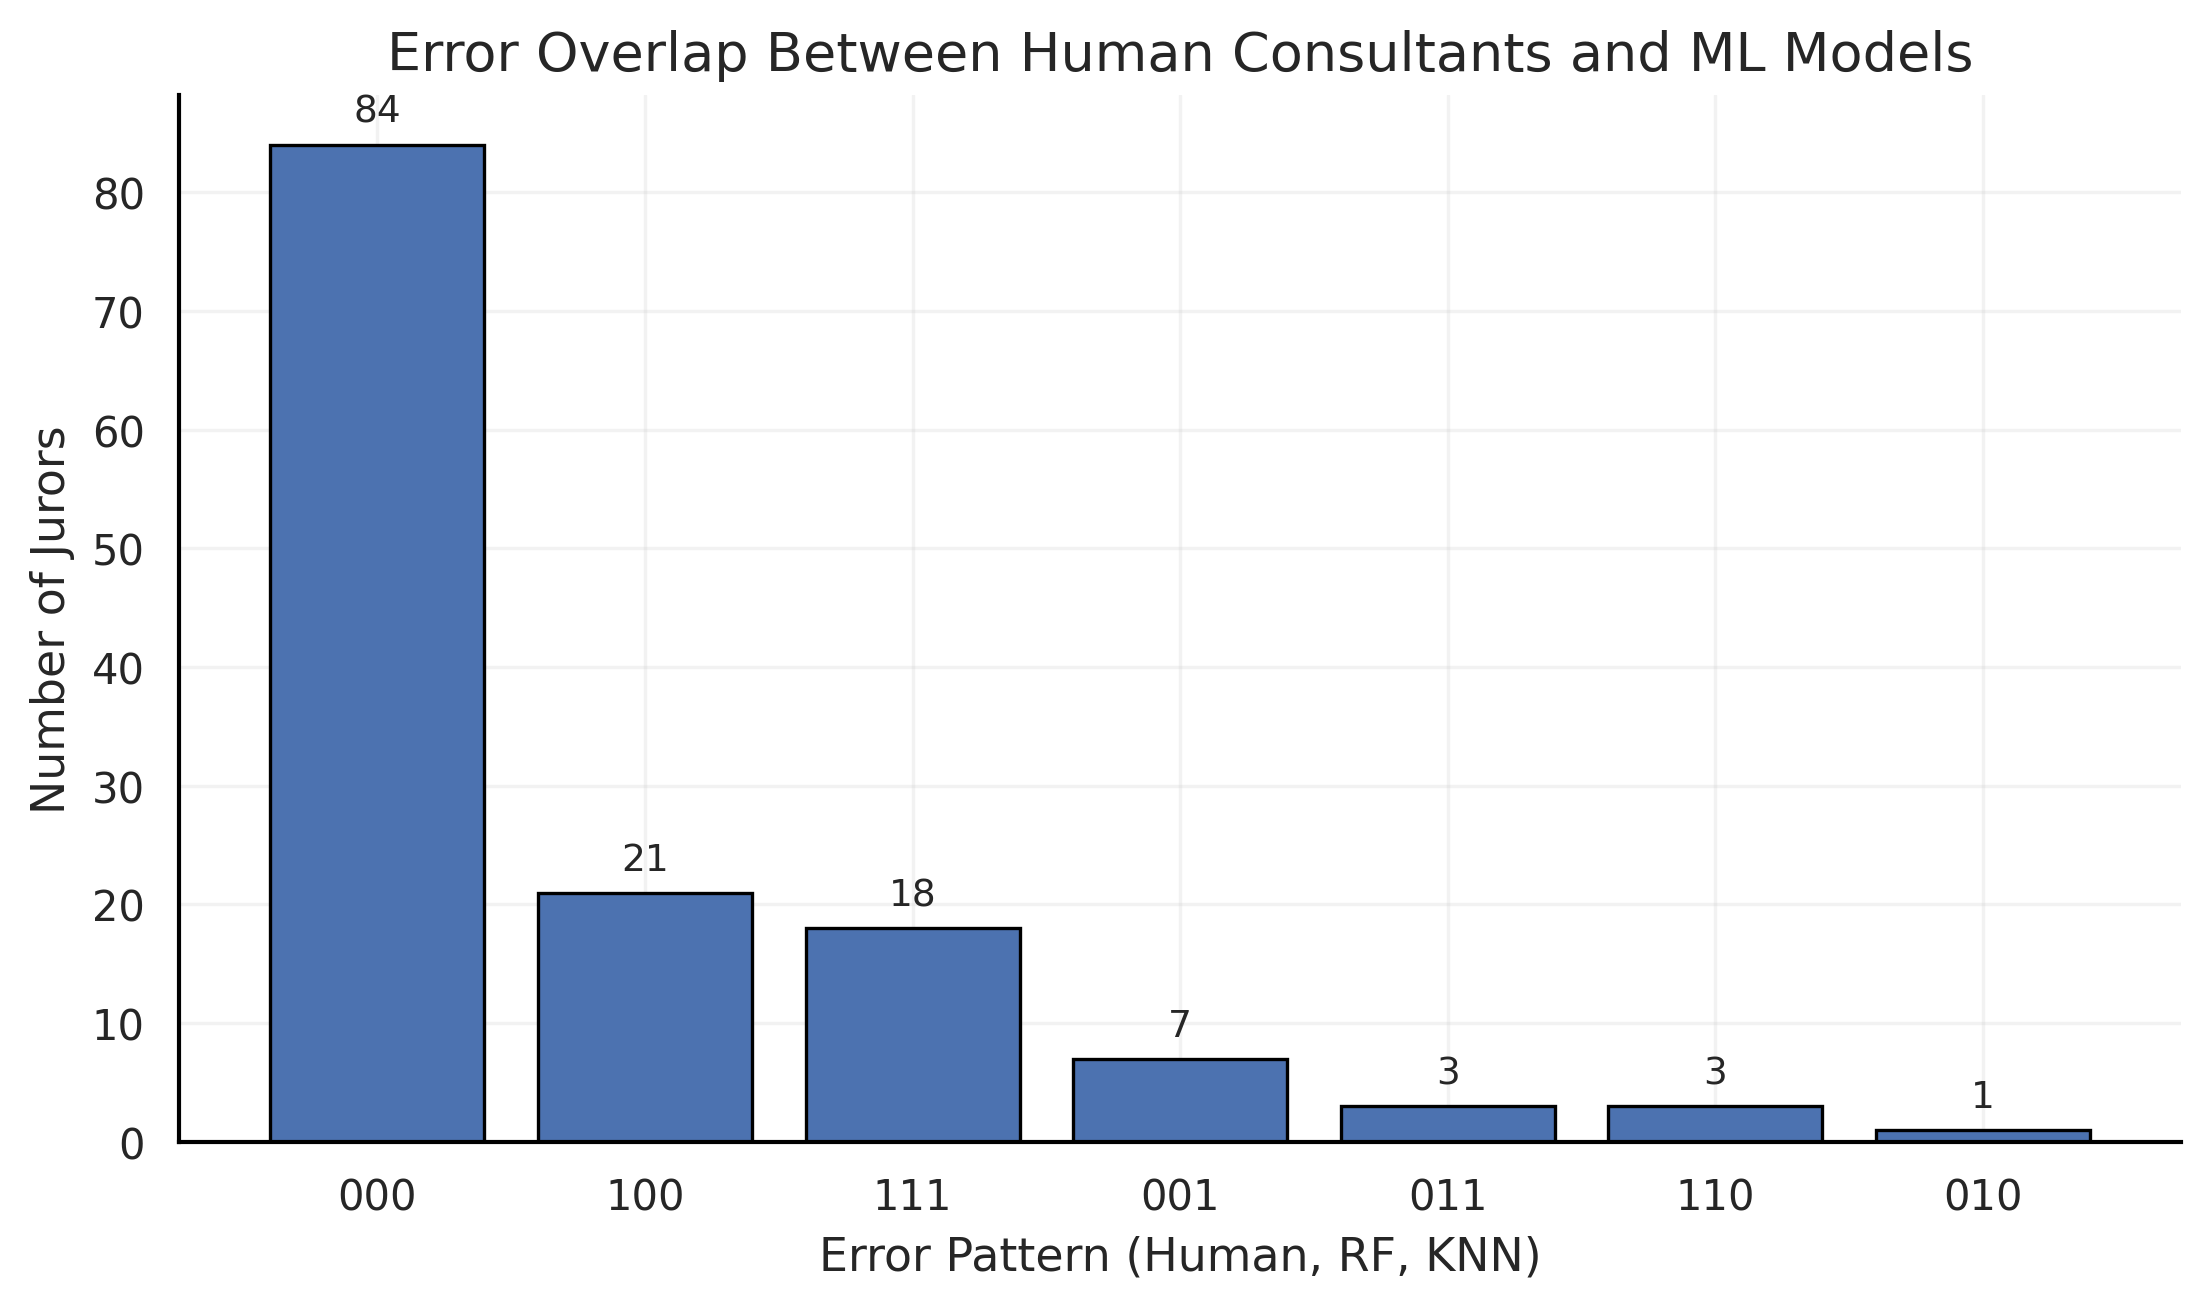

In [7]:
# Sort patterns by frequency so the chart is easier to read
plot_df = pattern_counts.sort_values("count", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

bars = ax.bar(
    plot_df["error_pattern"],
    plot_df["count"],
    edgecolor="black",
    linewidth=0.8,
)

# Add count labels above the bars
offset = plot_df["count"].max() * 0.015
for bar, count in zip(bars, plot_df["count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xlabel("Error Pattern (Human, RF, KNN)")
ax.set_ylabel("Number of Jurors")
ax.set_title("Error Overlap Between Human Consultants and ML Models")

# Keep the plot clean and paper-friendly
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("error_overlap_human_vs_models.png", dpi=300, bbox_inches="tight")
plt.savefig("error_overlap_human_vs_models.pdf", bbox_inches="tight")
plt.show()

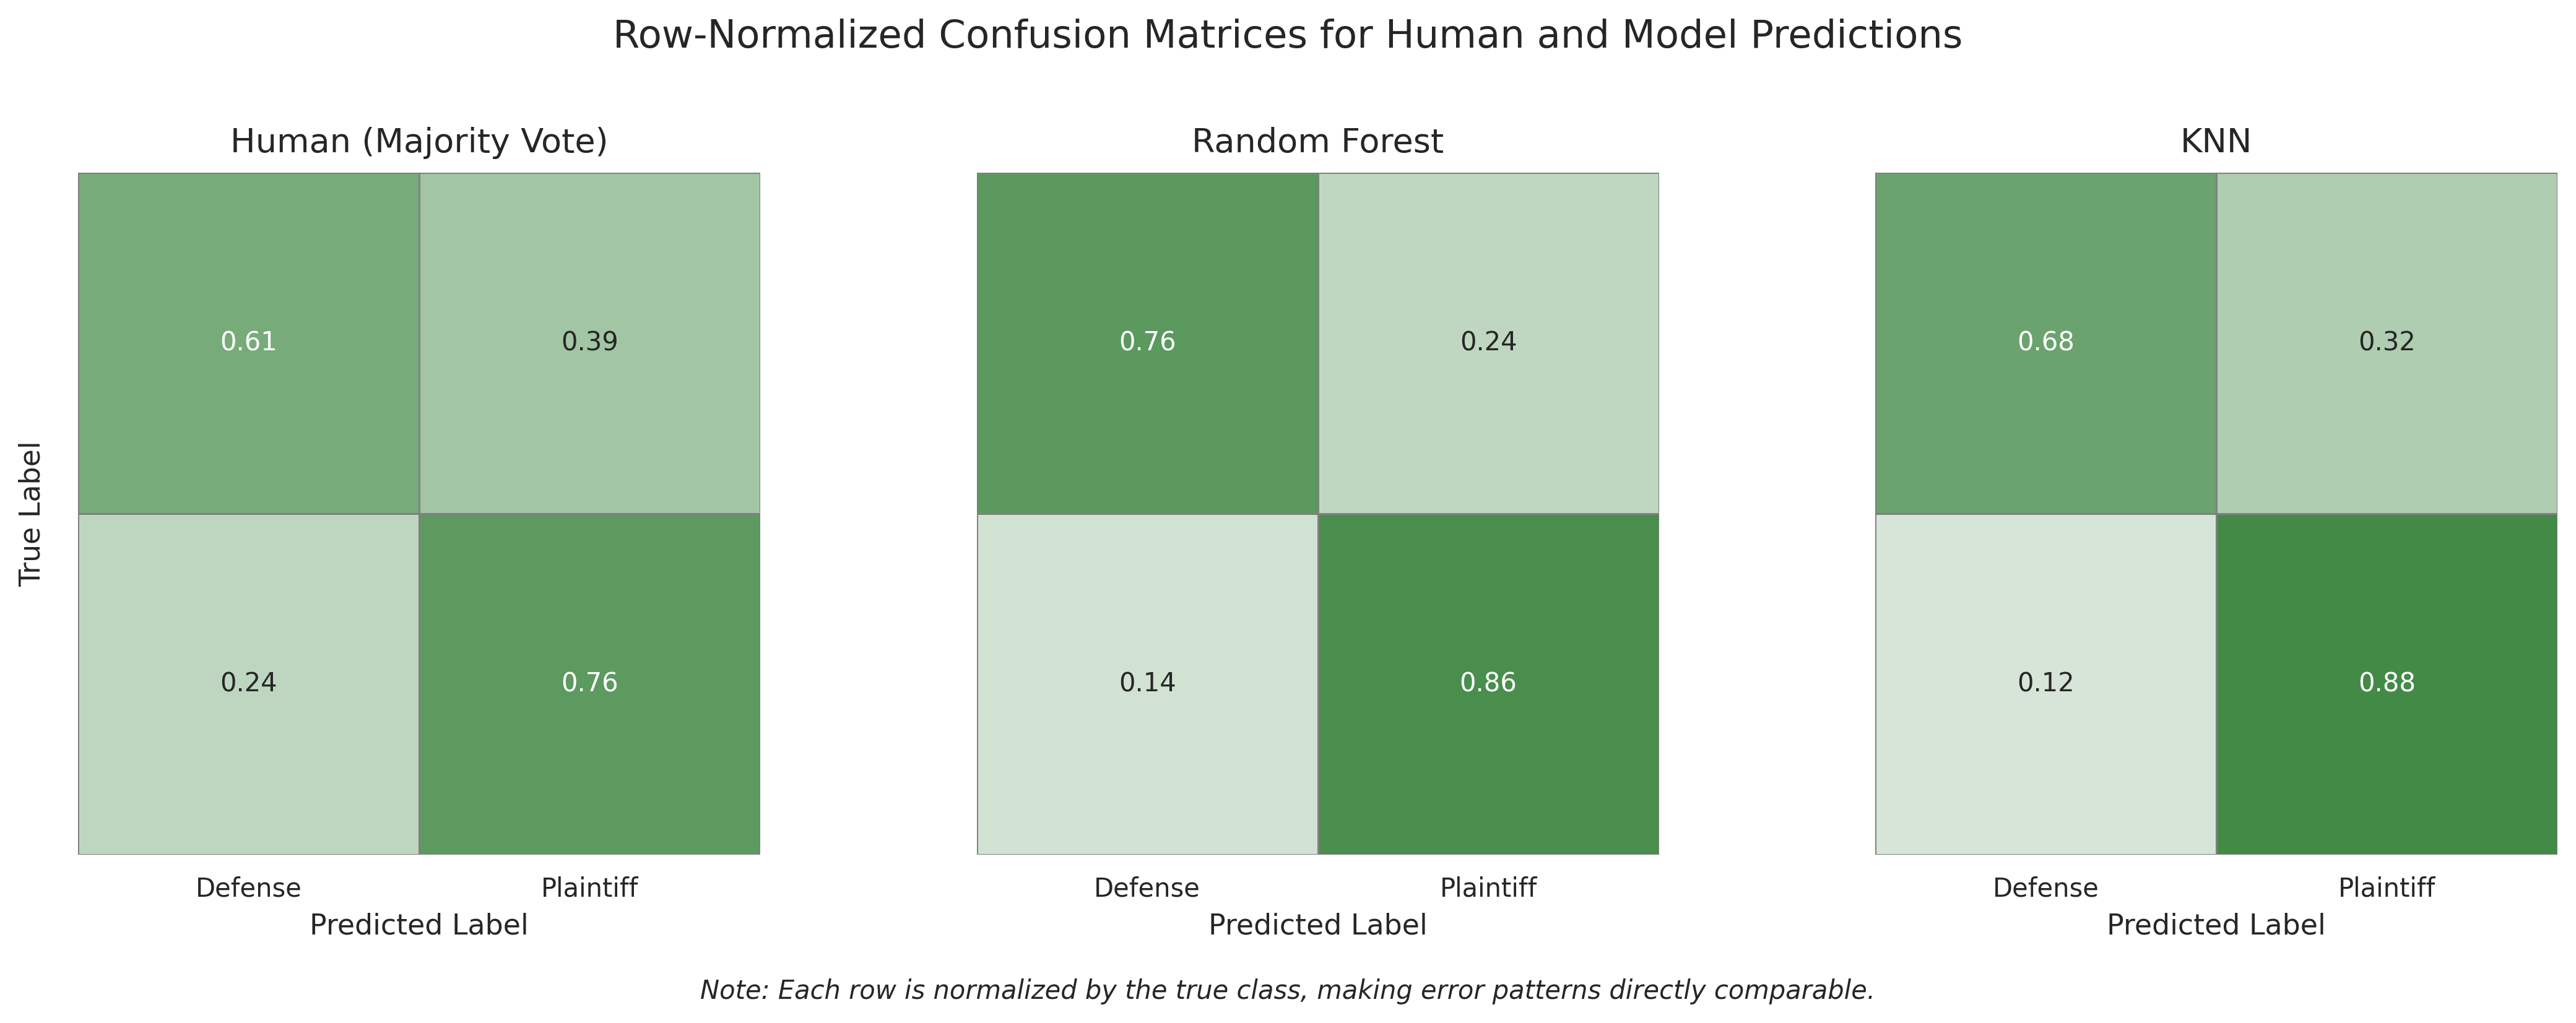

In [8]:
models = {
    "Human (Majority Vote)": y_human,
    "Random Forest": y_rf,
    "KNN": y_knn,
}

# Use a single color scale across all panels so values are directly comparable
vmin, vmax = 0.0, 1.0
cmap = sns.light_palette("#2E7D32", as_cmap=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, (model_name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, y_pred, normalize="true")

    sns.heatmap(
        cm,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        square=True,
        linewidths=0.6,
        linecolor="gray",
        annot_kws={"size": 10},
    )

    ax.set_title(model_name, pad=8)
    ax.set_xlabel("Predicted Label")
    ax.set_xticklabels(["Defense", "Plaintiff"])

    if ax is axes[0]:
        ax.set_ylabel("True Label")
        ax.set_yticklabels(["Defense", "Plaintiff"], rotation=0)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Row-Normalized Confusion Matrices for Human and Model Predictions",
    fontsize=15,
    y=1.04,
)

fig.text(
    0.5,
    -0.06,
    "Note: Each row is normalized by the true class, making error patterns directly comparable.",
    ha="center",
    fontsize=10,
    style="italic",
)

plt.tight_layout()
plt.savefig("confusion_matrices_human_rf_knn.png", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrices_human_rf_knn.pdf", bbox_inches="tight")
plt.show()

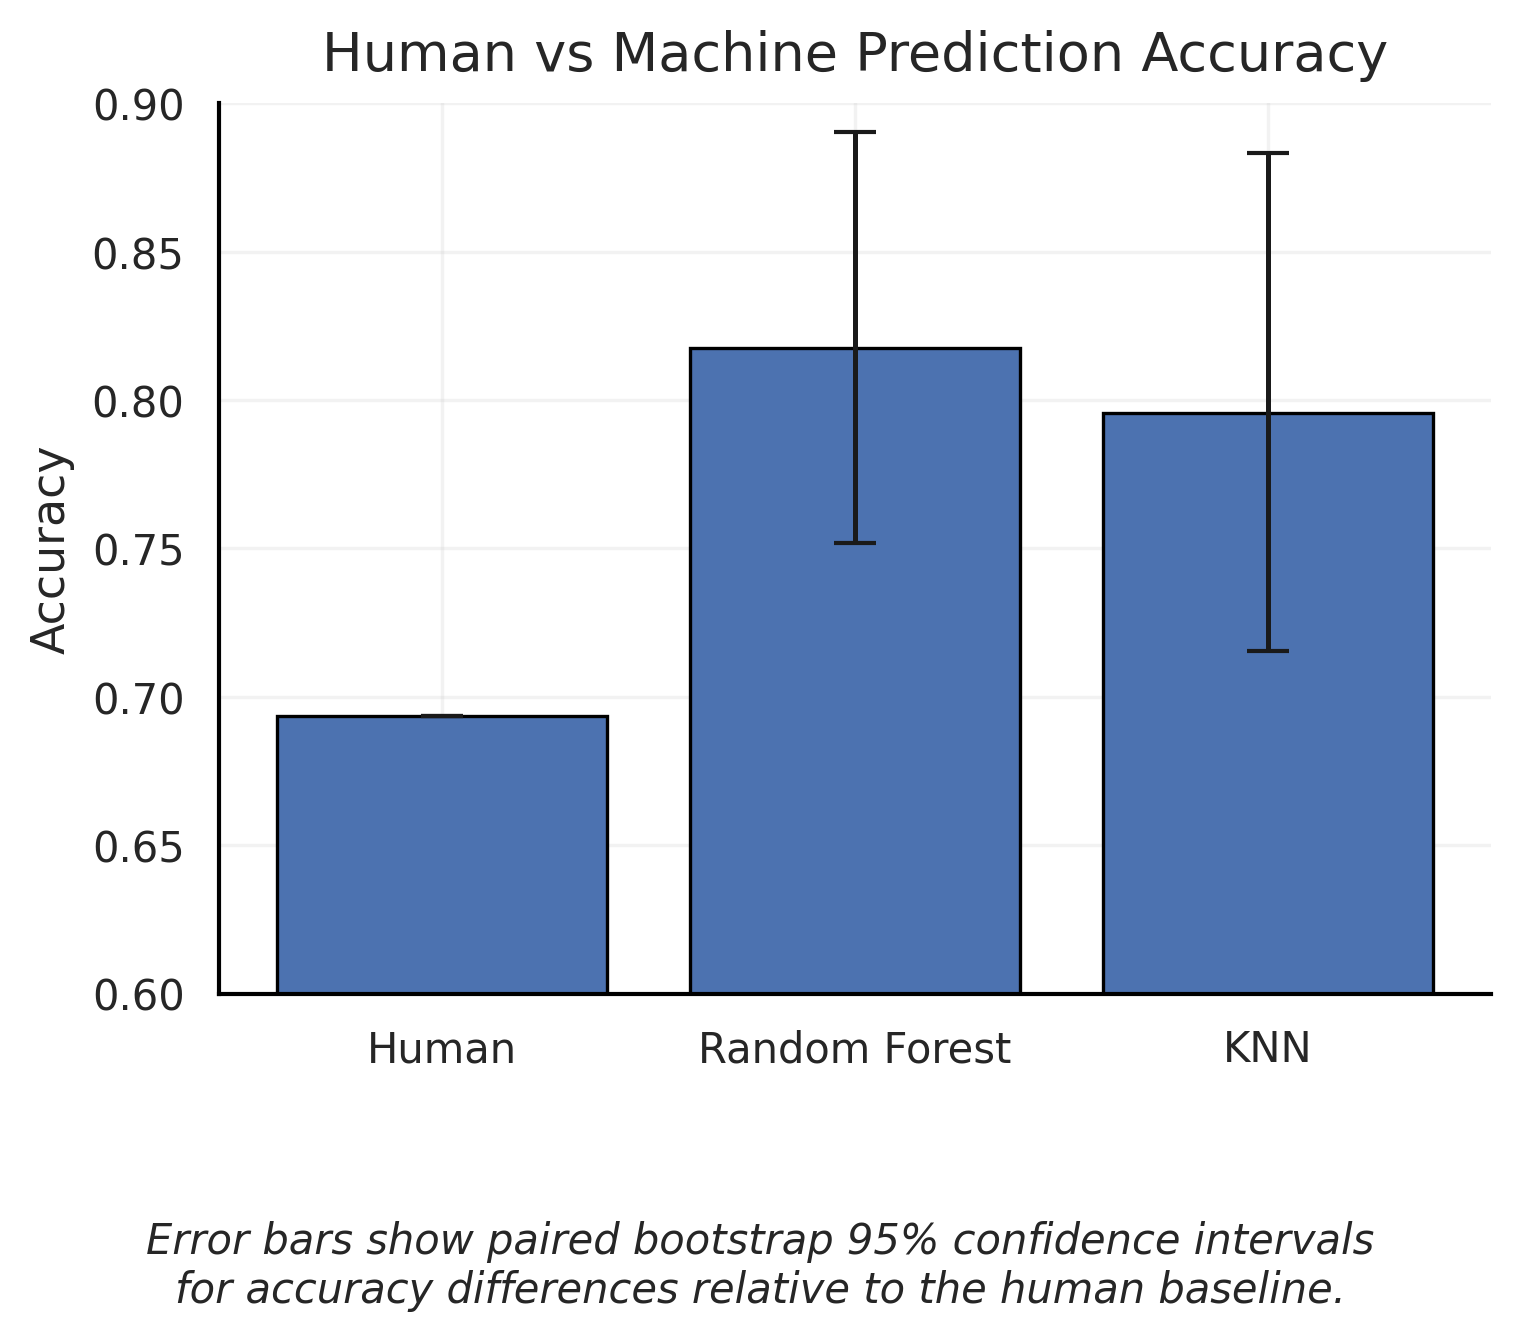

In [9]:
# Pull the exact values from the computed results table instead of hardcoding numbers
plot_rows = []

# Human baseline
human_row = results_df.loc[results_df["Model"] == "Human (Majority Vote)"].iloc[0]
plot_rows.append({
    "Model": "Human",
    "Accuracy": human_row["Accuracy"],
    "ci_low": np.nan,
    "ci_high": np.nan,
})

# Random Forest
rf_row = results_df.loc[results_df["Model"] == "Random Forest"].iloc[0]
plot_rows.append({
    "Model": "Random Forest",
    "Accuracy": rf_row["Accuracy"],
    "ci_low": human_row["Accuracy"] + rf_row["Delta_CI_Low"],
    "ci_high": human_row["Accuracy"] + rf_row["Delta_CI_High"],
})

# KNN
knn_row = results_df.loc[results_df["Model"] == "KNN"].iloc[0]
plot_rows.append({
    "Model": "KNN",
    "Accuracy": knn_row["Accuracy"],
    "ci_low": human_row["Accuracy"] + knn_row["Delta_CI_Low"],
    "ci_high": human_row["Accuracy"] + knn_row["Delta_CI_High"],
})

accuracy_plot_df = pd.DataFrame(plot_rows)

# Convert CI endpoints into asymmetric error bars for matplotlib
accuracy_plot_df["err_low"] = accuracy_plot_df["Accuracy"] - accuracy_plot_df["ci_low"]
accuracy_plot_df["err_high"] = accuracy_plot_df["ci_high"] - accuracy_plot_df["Accuracy"]
accuracy_plot_df[["err_low", "err_high"]] = accuracy_plot_df[["err_low", "err_high"]].fillna(0)

fig, ax = plt.subplots(figsize=(5.2, 3.8))

x = np.arange(len(accuracy_plot_df))

bars = ax.bar(
    x,
    accuracy_plot_df["Accuracy"],
    yerr=[accuracy_plot_df["err_low"], accuracy_plot_df["err_high"]],
    capsize=5,
    edgecolor="black",
    linewidth=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(accuracy_plot_df["Model"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0.6, 0.9)
ax.set_title("Human vs Machine Prediction Accuracy", pad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

fig.text(
    0.5,
    -0.16,
    "Error bars show paired bootstrap 95% confidence intervals\nfor accuracy differences relative to the human baseline.",
    ha="center",
    fontsize=10,
    style="italic",
)

plt.tight_layout()
plt.savefig("teaser_human_vs_ml_accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig("teaser_human_vs_ml_accuracy.pdf", bbox_inches="tight")
plt.show()

In [10]:
# Save the main evaluation table for reuse in paper writing or downstream analysis
results_df.to_csv("model_vs_human_evaluation_summary.csv", index=False)

print("Saved:")
print(" - model_vs_human_evaluation_summary.csv")
print(" - error_overlap_human_vs_models.png / .pdf")
print(" - confusion_matrices_human_rf_knn.png / .pdf")
print(" - teaser_human_vs_ml_accuracy.png / .pdf")

Saved:
 - model_vs_human_evaluation_summary.csv
 - error_overlap_human_vs_models.png / .pdf
 - confusion_matrices_human_rf_knn.png / .pdf
 - teaser_human_vs_ml_accuracy.png / .pdf
